## Signal processing using python

This is a notebook to help walk you through the process of downloading raw time-domain data and processing the NMR spectrum yourself. The raw data generated with the spectrometer can be transferred and analyzed with your favourite software. Here we show how to do that in jupyter lab.

First, we need to Export the raw data in the ".csv" format. To do that, click on the time domain data and choose the "Export" icon on the right. Then choose "Export current data as Text file (.csv)". This will save the data in the "C:\Data\Group# Data" folder which can be transferred using "file transfer" in the TeamViewer or AnyDesk. Then import the data using the proper path. The raw data generated with the spectrometer can be transferred and analyzed with your favorite software. Here we show how to do that in jupyter lab.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the data
try:
    FID_water=pd.read_csv("{directory}/{filename}.csv", header=None)
    print(f"Data loaded successfully from {file_name}.csv")
except FileNotFoundError:
    print("Error: File not found. Please ensure the file exists in the specified directory.")
    raise


Note that this should be a list of complex data points, where the first row is the index, the second row is the real part and the third row is the imaginary part, as shown in this example data:

In [ ]:
# Step 2: Display basic information about the data
print("Preview of the loaded data:")
print(FID_water.head())
print(f"Data shape: {FID_water.shape}")

(8192, 3)

In [ ]:
FID_water

,0,1,2
0,0,3669.41000,0.000000
1,1,3642.08000,462.530000
2,2,3566.32000,860.791000
3,3,3452.28000,1225.360000
4,4,3307.01000,1553.800000
...,...,...,...
8187,8187,6.06859,-1.781070
8188,8188,7.03166,-0.745456
8189,8189,7.69956,1.530270
8190,8190,7.97660,0.789827


Let's plot the Re and Im components to make sure the data has the right structure. Here I have applied an offset of 400 to Imaginary points to separate the plots. The result should look like:  

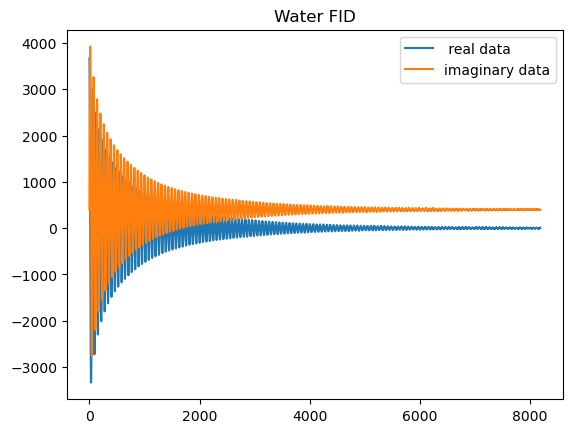

In [ ]:
# Step 3: Plot the raw data
try:
    time = FID_water.iloc[0]  # Assuming the first row is the x-axis (time)
    real_part = FID_water.iloc[1]  # Assuming the second row is the real part
    imag_part = FID_water.iloc[2]  # Assuming the third row is the imaginary part

    plt.figure(figsize=(10, 6))
    plt.plot(time, real_part, label="Real Part", alpha=0.7)
    plt.plot(time, imag_part+400, label="Imaginary Part", alpha=0.7)
    plt.title("Raw Time-Domain Data")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid()
    plt.show()
except IndexError:
    print("Error: The data does not have the expected structure (time, real, imaginary parts). Please check your file.")
    raise
    

To see the spectrum, the data is transferred using the FFT algorithm. The resulting spectrum should depend on the Number of points in the experiment, N, and the dwell time, Tdw(s). The result of FFT should be shifted to reflect the correct position of the peak.
In this section you need to complete the code to apply a Fourier transform and plot the data. The results should be similar to the following figure.

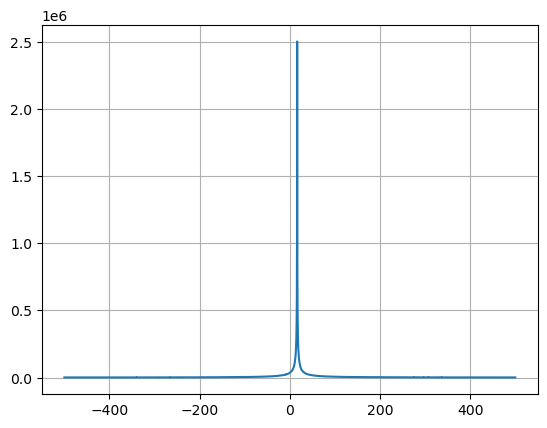

In [ ]:
# Step 5: Perform Fourier Transform and Save Results
try:
    # User-defined dwell time (dw)
    Tdw = float(input("Enter the dwell time (in seconds): "))

    # Scale time using dwell time
    time = time_index * Tdw

    # Combine real and imaginary parts into complex data
    complex_data = real_part + 1j * imag_part

    # Perform FFT and shift frequencies
    ft_signal = fft(complex_data)
    ft_signal = fftshift(ft_signal)  # Center the spectrum

    # Generate frequency axis
    n_points = len(time)
    freq_axis = np.fft.fftfreq(n_points, d=Tdw)
    freq_axis = np.fft.fftshift(freq_axis)  # Align frequency axis with FT

    freq_axis = (freq_axis / spectrometer_frequency) * 1e6
    x_label = "Frequency (ppm)"

    # Plot the frequency spectrum
    plt.figure(figsize=(10, 6))
    plt.plot(freq_axis, np.real(ft_signal), label="FT Real Part", alpha=0.7)
    plt.plot(freq_axis, np.imag(ft_signal), label="FT Imaginary Part", alpha=0.7, linestyle="--")
    plt.title("Fourier Transform Spectrum")
    plt.xlabel(x_label)
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.grid()
    plt.show()

    # Save the processed results
    processed_file_name = file_name + "_processed.csv"
    processed_data = pd.DataFrame({"Frequency": freq_axis, "FT Real": np.real(ft_signal), "FT Imaginary": np.imag(ft_signal)})
    processed_data.to_csv(processed_file_name, index=False)
    print(f"Processed data saved to {processed_file_name}")
except Exception as e:
    print(f"Error during processing: {e}"

Please note that the this notebook reflects the general steps that needd to be followed and does not reflect the signals from experiments that you have performed. 